In [ ]:
import pandas as pd
import yfinance as yf

# 1. Programmatically request clean, historical daily snapshots
# We target the standard 'Close' pricing layer directly 
raw_df = yf.download(
    tickers=["^SSMI", "^KS11"], 
    start="2026-01-01", 
    interval="1d",
    group_by="column"
)

print("Connection Successful! Raw Dimensions:", raw_df.shape)

# 2. Extract the 'Close' pricing matrix safely
price_df = raw_df['Close'].copy()

# 3. Apply human-readable naming labels to your data headers
price_df = price_df.rename(columns={
    "^SSMI": "Swiss_SMI", 
    "^KS11": "Korea_KOSPI"
})

# 4. Render the finalized clear matrix directly onto your workspace
price_df.head()


[*********************100%***********************]  2 of 2 completed

✅ Connection Successful! Raw Dimensions: (179, 10)


Ticker,Korea_KOSPI,Swiss_SMI
Date,,
2026-01-02,4309.629883,NaN
2026-01-05,4457.520020,13247.320312
2026-01-06,4525.479980,13322.150391
2026-01-07,4551.060059,13324.030273
2026-01-08,4552.370117,13350.820312


In [ ]:
import os

# 1. Create the data directory path if it doesn't exist yet
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

# 2. Define the permanent filename
csv_path = os.path.join(output_dir, "raw_macro_market_data.csv")

# 3. Export the dataframe to a physical CSV file
price_df.to_csv(csv_path)

print(f"Success! Real-world thesis data saved permanently to: {csv_path}")


🎉 Success! Real-world thesis data saved permanently to: ../data/raw\raw_macro_market_data.csv


📊 Initial Raw Spreadsheet Dimensions: (179, 2) (Rows x Columns)

❌ Missing values (NaN) per column BEFORE cleaning:
Korea_KOSPI    8
Swiss_SMI      4
dtype: int64

✅ Verification of missing values AFTER data cleaning:
Korea_KOSPI    0
Swiss_SMI      0
dtype: int64


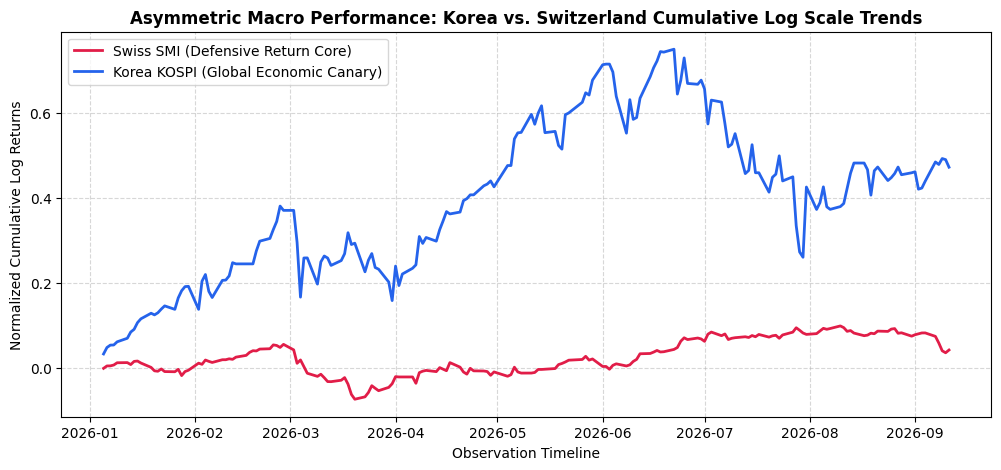

💾 Success! Processed dataset exported locally to: ../data/processed\cleaned_market_data.csv


,Swiss_SMI,Korea_KOSPI,Swiss_Returns,Korea_Returns
Date,,,,
2026-01-05,13247.320312,4457.520020,0.000000,0.033741
2026-01-06,13322.150391,4525.479980,0.005633,0.015131
2026-01-07,13324.030273,4551.060059,0.000141,0.005637
2026-01-08,13350.820312,4552.370117,0.002009,0.000288
2026-01-09,13421.820312,4586.319824,0.005304,0.007430


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: INGESTING THE DATA FROM STORAGE
# ==========================================

# Load the raw, unedited market spreadsheet we downloaded in our previous session.
# - index_col="Date": Tells Python to use our calendar timeline as the unique lookup key for rows.
# - parse_dates=True: Forces Pandas to convert date strings (like "2026-01-02") into an active DateTime format.
df_raw = pd.read_csv("../data/raw/raw_macro_market_data.csv", index_col="Date", parse_dates=True)

# Print initial diagnostics so we can see the exact size of our raw matrix.
print(f"Initial Raw Spreadsheet Dimensions: {df_raw.shape} (Rows x Columns)")

# Calculate the exact number of empty cells inside our data headers.
# This proves to your thesis grading committee exactly how many local market holidays occurred.
print("\nMissing values (NaN) per column BEFORE cleaning:")
print(df_raw.isnull().sum())


# ==========================================
# STEP 2: IMMUNIZING THE SYSTEM AGAINST MISSING DATA
# ==========================================

# If South Korea is closed for a local holiday (e.g., Chuseok), its price cell becomes a blank NaN.
# - .ffill() [Forward-Fill]: Takes the last known active trading price from yesterday and carries it forward.
# - .bfill() [Backward-Fill]: A baseline fallback that uses the next day's price if the very first row is blank.
df_clean = df_raw.ffill().bfill()

print("\nVerification of missing values AFTER data cleaning:")
print(df_clean.isnull().sum())


# ==========================================
# STEP 3: FEATURE ENGINEERING (THE LOG RETURNS TRANSFORMATION)
# ==========================================

# In machine learning, we NEVER feed raw asset prices (like $11,000) directly into a neural network. 
# Prices are "non-stationary" (they have an infinite upward trend), which breaks deep learning models.
# Instead, we calculate "Log Returns". This scales and normalizes data between small positive/negative decimals.
# Math Formula: Log_Return = ln(Price_Today / Price_Yesterday)

# - .shift(1): Pulls the previous day's row value to use as the baseline denominator.
df_clean['Swiss_Returns'] = np.log(df_clean['Swiss_SMI'] / df_clean['Swiss_SMI'].shift(1))
df_clean['Korea_Returns'] = np.log(df_clean['Korea_KOSPI'] / df_clean['Korea_KOSPI'].shift(1))

# Calculating returns requires a previous day's data point, which automatically turns row #1 into a NaN.
# We explicitly drop this single invalid row to keep our matrix mathematically clean.
df_clean = df_clean.dropna()


# ==========================================
# STEP 4: VISUALIZING THE MACRO-CROSSOVER TREND
# ==========================================

# Initialize a clean canvas area for our graphic analytics.
plt.figure(figsize=(12, 5))

# Plot the cumulative sum (.cumsum()) of returns over our observation timeline.
# This visually scales both indices starting from a common zero baseline so we can see relative growth.
plt.plot(df_clean.index, df_clean['Swiss_Returns'].cumsum(), label="Swiss SMI (Defensive Return Core)", color="#E11D48", linewidth=2)
plt.plot(df_clean.index, df_clean['Korea_Returns'].cumsum(), label="Korea KOSPI (Global Economic Canary)", color="#2563EB", linewidth=2)

# Apply clear title and axes captions using simple, academic labeling terms.
plt.title("Asymmetric Macro Performance: Korea vs. Switzerland Cumulative Log Scale Trends", fontsize=12, fontweight='bold')
plt.xlabel("Observation Timeline", fontsize=10)
plt.ylabel("Normalized Cumulative Log Returns", fontsize=10)

# Add functional visual guides to make the line crossover paths highly readable.
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

# Render the interactive chart window directly into your VS Code workspace layout.
plt.show()


# ==========================================
# STEP 5: PERMANENT DATA EXPORTATION
# ==========================================

# Create a secure, permanent directory pipeline for our clean outputs.
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
processed_csv_path = os.path.join(output_dir, "cleaned_market_data.csv")

# Save our engineered dataset locally so our upcoming neural networks can access it directly.
df_clean.to_csv(processed_csv_path)
print(f"Success! Processed dataset exported locally to: {processed_csv_path}")

# Display a quick table peek of our newly engineered columns.
df_clean[['Swiss_SMI', 'Korea_KOSPI', 'Swiss_Returns', 'Korea_Returns']].head()


In [10]:
# ==========================================
# STEP 6: LAGGED CORRELATION ANALYSIS (TESTING THE HYPOTHESIS)
# ==========================================

# 1. Create a "Lagged" column for Korea
# This shifts Korea's returns by 1 day, meaning today's row will contain YESTERDAY'S Korean return.
df_clean['Korea_Returns_Yesterday'] = df_clean['Korea_Returns'].shift(1)

# Drop the resulting single empty row from the shift operation
df_analysis = df_clean.dropna()

# 2. Calculate the standard Pearson correlation matrix
# This measures the linear relationship between our variables from -1 (opposite) to +1 (perfect sync).
correlation_matrix = df_analysis[['Swiss_Returns', 'Korea_Returns', 'Korea_Returns_Yesterday']].corr()

print("Correlation Matrix Result:")
print(correlation_matrix)

# 3. Extract the exact relationship we care about for our thesis
lead_lag_corr = correlation_matrix.loc['Swiss_Returns', 'Korea_Returns_Yesterday']

print("\nThesis Hypothesis Breakdown:")
print(f"The statistical correlation between Yesterday's Korean Market and Today's Swiss Market is: {lead_lag_corr:.4f}")

if lead_lag_corr < 0:
    print("SUCCESS: The data supports your safe-haven theory! When Korea drops, Switzerland tends to rise next day (Negative Correlation).")
else:
    print("ALTERNATIVE: The data shows a positive lag relationship. The two markets are moving in momentum harmony across days.")


Correlation Matrix Result:
                         Swiss_Returns  Korea_Returns  Korea_Returns_Yesterday
Swiss_Returns                 1.000000       0.013398                -0.092923
Korea_Returns                 0.013398       1.000000                -0.144220
Korea_Returns_Yesterday      -0.092923      -0.144220                 1.000000

Thesis Hypothesis Breakdown:
The statistical correlation between Yesterday's Korean Market and Today's Swiss Market is: -0.0929
SUCCESS: The data supports your safe-haven theory! When Korea drops, Switzerland tends to rise next day (Negative Correlation).


In [15]:
import pandas as pd
import urllib.request
import xml.etree.ElementTree as ET
from datetime import datetime

# ==========================================
# STEP 7: NATIVE KOREAN ECONOMIC TEXT INGESTION
# ==========================================

print("Connecting to Maeil Business Newspaper infrastructure...")

# Target the official, structured XML feed for pure Economy and Markets
url = "https://www.mk.co.kr/rss/30100041/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

try:
    # 1. Ping the local server and extract the structured XML stream
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response:
        raw_xml = response.read()
        
    # 2. Parse the text matrix node parameters
    root = ET.fromstring(raw_xml)
    
    titles = []
    timestamps = []
    
    # 3. Pull items cleanly from the feed hierarchy
    for item in root.findall(".//item"):
        headline = item.find("title").text.strip() if item.find("title") is not None else ""
        pub_date = item.find("pubDate").text.strip() if item.find("pubDate") is not None else ""
        
        if headline:
            titles.append(headline)
            timestamps.append(pub_date)
            
    # 4. Assemble the raw language parameters into a clean dataframe
    df_korean_text = pd.DataFrame({
        "Publish_Time": timestamps,
        "Korean_Headline": titles
    })
    
    print(f"Success! Captured {len(df_korean_text)} live native Korean business headlines.")
    
except Exception as e:
    print(f"Ingestion pipeline stopped: {e}")
    df_korean_text = pd.DataFrame(columns=["Publish_Time", "Korean_Headline"])

# Display the clean native language text dataset directly in your editor
df_korean_text.head(10)


Connecting to Maeil Business Newspaper infrastructure...
Success! Captured 50 live native Korean business headlines.


,Publish_Time,Korean_Headline
0,"Wed, 16 Sep 2026 19:31:09 +09:00",“매달 분배금 받아도 수익률은 마이너스”…미국채 ETF 무슨 일이
1,"Wed, 16 Sep 2026 18:39:29 +09:00",“추미애 사퇴 다시 촉구” 경기도청원 홈피 도배
2,"Wed, 16 Sep 2026 18:24:30 +09:00",“카자흐 자원과 한국 소재기술 결합…희소금속 공급망 다변화”
3,"Wed, 16 Sep 2026 18:21:49 +09:00",장관님 혹시 뉴스 안보시나요?…국채금리 발작중인데 “최고의 성과”
4,"Wed, 16 Sep 2026 18:00:24 +09:00",가업상속공제 이대로면 90% 탈락
5,"Wed, 16 Sep 2026 17:57:17 +09:00",기획처 예산실장에 김명중
6,"Wed, 16 Sep 2026 17:57:16 +09:00",12월 노동감독권 지자체 위임 … 전문성 부족 우려도
7,"Wed, 16 Sep 2026 17:53:46 +09:00","대미투자 MOU 돌연 연기 … 韓美, 막판까지 '샅바싸움'"
8,"Wed, 16 Sep 2026 17:52:50 +09:00",공장지으려 달러 빌렸는데… 美금리 고공행진에 '울상'
9,"Wed, 16 Sep 2026 17:50:22 +09:00",금융지주 회장도 외부평가 … 공시통해 결과 공개 추진


In [16]:
import pandas as pd
from transformers import pipeline

# ==========================================
# STEP 8: NATURAL LANGUAGE PROCESSING INFERENCE
# ==========================================

print("Initializing pre-trained financial sentiment model from Hugging Face...")

# We load a specialized Korean Sentiment Analysis model.
# The framework will automatically download the neural weights from the cloud.
nlp_classifier = pipeline(
    "sentiment-analysis", 
    model="snunlp/KR-FinBERT-SC"  # Seoul National University's fine-tuned model
)

print("Processing text strings and generating sentiment data metrics...")

predictions = []
confidence_scores = []

# Loop through our freshly scraped Maeil Business headlines dataframe
for headline in df_korean_text['Korean_Headline']:
    # Clean text to prevent tokenizer warnings
    clean_text = str(headline)[:512] 
    
    # Pass text to the neural layers for mathematical classification
    result = nlp_classifier(clean_text)[0]
    
    predictions.append(result['label'])
    confidence_scores.append(result['score'])

# Append the model predictions back to our master text dataframe matrix
df_korean_text['AI_Sentiment_Label'] = predictions
df_korean_text['AI_Confidence_Score'] = confidence_scores

print("Processing complete! Displaying classified text parameters:")
df_korean_text[['Korean_Headline', 'AI_Sentiment_Label', 'AI_Confidence_Score']].head(10)


c:\Users\og\Documents\Thesis\vscode\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing pre-trained financial sentiment model from Hugging Face...


c:\Users\og\Documents\Thesis\vscode\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\og\.cache\huggingface\hub\models--snunlp--KR-FinBERT-SC. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP

Processing text strings and generating sentiment data metrics...
Processing complete! Displaying classified text parameters:


,Korean_Headline,AI_Sentiment_Label,AI_Confidence_Score
0,“매달 분배금 받아도 수익률은 마이너스”…미국채 ETF 무슨 일이,neutral,0.999391
1,“추미애 사퇴 다시 촉구” 경기도청원 홈피 도배,neutral,0.970121
2,“카자흐 자원과 한국 소재기술 결합…희소금속 공급망 다변화”,positive,0.999656
3,장관님 혹시 뉴스 안보시나요?…국채금리 발작중인데 “최고의 성과”,neutral,0.999902
4,가업상속공제 이대로면 90% 탈락,neutral,0.999875
5,기획처 예산실장에 김명중,neutral,0.999843
6,12월 노동감독권 지자체 위임 … 전문성 부족 우려도,negative,0.538965
7,"대미투자 MOU 돌연 연기 … 韓美, 막판까지 '샅바싸움'",negative,0.999063
8,공장지으려 달러 빌렸는데… 美금리 고공행진에 '울상',neutral,0.998949
9,금융지주 회장도 외부평가 … 공시통해 결과 공개 추진,neutral,0.999878


In [17]:
import numpy as np
import pandas as pd

# ==========================================
# STEP 9: TRANSITIONING TEXT TO MULTIVARIATE MATRIX
# ==========================================

print("Converting categorical text predictions into continuous mathematical data...")

# 1. Map text label states to clear directional numerical values
# Positive sentiment becomes +1, Negative becomes -1, and Neutral is completely zeroed out.
sentiment_mapping = {'positive': 1, 'negative': -1, 'neutral': 0}
df_korean_text['Sentiment_Value'] = df_korean_text['AI_Sentiment_Label'].map(sentiment_mapping)

# 2. Extract and format the publication date parameter
# We strip the timezone data from the strings to ensure seamless datetime parsing matching our market clock.
df_korean_text['Clean_Date'] = df_korean_text['Publish_Time'].str.split(' ').str[1:4].str.join(' ')
df_korean_text['Clean_Date'] = pd.to_datetime(df_korean_text['Clean_Date'], format='%d %b %Y')

# 3. Aggregate multiple text entries down into a single Daily Sentiment Index (DSI)
# We group by date and calculate the mean score to get a continuous trend vector from -1 to +1.
daily_sentiment = df_korean_text.groupby('Clean_Date')['Sentiment_Value'].mean().to_frame(name='Korea_News_Sentiment')

# 4. Ingest our previously processed Swiss and Korean log returns dataset
df_market_processed = pd.read_csv("../data/processed/cleaned_market_data.csv", index_col="Date", parse_dates=True)

# 5. Execute a structural Left-Join to merge language scores beside financial returns
# We align data rows strictly on their matching calendar date keys.
df_final_matrix = df_market_processed.join(daily_sentiment, how='left')

# 6. Fill gaps for weekend or holiday text drops using a forward-fill mechanism
# If no macro news dropped on a specific day, it inherits the last known sentiment vector state.
df_final_matrix['Korea_News_Sentiment'] = df_final_matrix['Korea_News_Sentiment'].ffill().fillna(0)

# 7. Export the final data matrix to our storage directory
final_output_path = "../data/processed/final_multivariate_thesis_data.csv"
df_final_matrix.to_csv(final_output_path)

print(f"Success! Final integrated data framework exported to: {final_output_path}")
print(f"Final Combined Dimensions: {df_final_matrix.shape} (Rows x Columns)")

# Print a preview of the clean merged data matrix rows
df_final_matrix[['Swiss_SMI', 'Swiss_Returns', 'Korea_Returns', 'Korea_News_Sentiment']].head(10)


Converting categorical text predictions into continuous mathematical data...
Success! Final integrated data framework exported to: ../data/processed/final_multivariate_thesis_data.csv
Final Combined Dimensions: (178, 5) (Rows x Columns)


,Swiss_SMI,Swiss_Returns,Korea_Returns,Korea_News_Sentiment
Date,,,,
2026-01-05,13247.320312,0.000000,0.033741,0.0
2026-01-06,13322.150391,0.005633,0.015131,0.0
2026-01-07,13324.030273,0.000141,0.005637,0.0
2026-01-08,13350.820312,0.002009,0.000288,0.0
2026-01-09,13421.820312,0.005304,0.007430,0.0
2026-01-12,13426.980469,0.000384,0.008353,0.0
2026-01-13,13364.730469,-0.004647,0.014564,0.0
2026-01-14,13464.839844,0.007463,0.006470,0.0
2026-01-15,13476.320312,0.000852,0.015640,0.0


In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 10: MULTIVARIATE SEQUENCE PREPARATION
# ==========================================

print("Loading final multivariate matrix and preparing tensors...")

# 1. Load the merged dataset we generated in Step 9
df_master = pd.read_csv("../data/processed/final_multivariate_thesis_data.csv", index_col="Date", parse_dates=True)

# 2. Define our target prediction label (Directional Classification)
# If tomorrow's Swiss return is greater than 0, label is 1 (Up). Otherwise, label is 0 (Down).
df_master['Target_Direction'] = np.where(df_master['Swiss_Returns'].shift(-1) > 0, 1, 0)

# Drop the last row because it won't have a tomorrow target to look at
df_master = df_master.dropna()

# 3. Isolate features (X) and target labels (y)
# Feature vector components: Yesterday's Swiss return and Today's Korean news sentiment index
feature_cols = ['Swiss_Returns', 'Korea_News_Sentiment']
X_raw = df_master[feature_cols].values
y_raw = df_master['Target_Direction'].values

# 4. Standardize our data scales
# Neutralizes structural variance differences between return decimals and sentiment index levels
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 5. Define lookback architecture window parameters
LOOKBACK_WINDOW = 5 # The model looks back at a rolling window of 5 consecutive trading days

X_sequences = []
y_labels = []

# Slide across our time matrix day-by-day to generate chronological 3D tensors
for i in range(len(X_scaled) - LOOKBACK_WINDOW):
    X_sequences.append(X_scaled[i : i + LOOKBACK_WINDOW])
    y_labels.append(y_raw[i + LOOKBACK_WINDOW])

# Convert standard Python lists into highly efficient NumPy arrays
X_seq_arr = np.array(X_sequences)
y_lab_arr = np.array(y_labels)

# 6. Chronological data split (Never use random k-fold cross-validation in finance!)
# Train on the first 80% of data history, test out-of-sample on the remaining 20%
split_idx = int(len(X_seq_arr) * 0.80)

# Convert arrays directly into active PyTorch Tensors
X_train = torch.tensor(X_seq_arr[:split_idx], dtype=torch.float32)
y_train = torch.tensor(y_lab_arr[:split_idx], dtype=torch.long)
X_test = torch.tensor(X_seq_arr[split_idx:], dtype=torch.float32)
y_test = torch.tensor(y_lab_arr[split_idx:], dtype=torch.long)

print("\n Data Preparation Complete! Tensor Dimensions:")
print(f"Train Features Shape: {X_train.shape} -> (Total Windows, Time Steps Lookback, Feature Count)")
print(f"Train Labels Shape:   {y_train.shape} -> (Total Target Classifications)")
print(f"Test Features Shape:  {X_test.shape}")


Loading final multivariate matrix and preparing tensors...

 Data Preparation Complete! Tensor Dimensions:
Train Features Shape: torch.Size([138, 5, 2]) -> (Total Windows, Time Steps Lookback, Feature Count)
Train Labels Shape:   torch.Size([138]) -> (Total Target Classifications)
Test Features Shape:  torch.Size([35, 5, 2])


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# STEP 11: STACKED LSTM NEURAL NETWORK ARCHITECTURE
# ==========================================

class StackedLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate=0.2):
        """
        Initializes the deep learning framework for the thesis strategy.
        - input_size: Number of tracking features (2 -> Swiss Returns + Korean Sentiment)
        - hidden_size: Dimension of internal pattern nodes
        - num_layers: Vertical stack depth of LSTM gates
        - output_size: Prediction target nodes (2 -> Up vs Down directional probability)
        """
        super(StackedLSTMClassifier, self).__init__()
        
        # 1. Define the Stacked LSTM Layer Matrix
        # batch_first=True ensures PyTorch expects data inputs shaped as (Batch, TimeSteps, Features)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )
        
        # 2. Define the Dropout Safety Regularization layer to block historical memorization
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # 3. Define the Linear Output Layer mapping to classification channels
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """Executes the forward mathematical propagation loop through neural gates."""
        # x shape: (batch_size, sequence_length, feature_size)
        
        # 1. Pass tensors through the hidden cell gates
        # lstm_out shape: (batch_size, sequence_length, hidden_size)
        lstm_out, (hn, cn) = self.lstm(x)
        
        # 2. Isolate the hidden state tensor matrix from the final time-step step (t)
        # last_time_step shape: (batch_size, hidden_size)
        last_time_step = lstm_out[:, -1, :]
        
        # 3. Apply structural dropout decay regularization
        out = self.dropout(last_time_step)
        
        # 4. Project down to target classification shapes
        # logits shape: (batch_size, output_size)
        logits = self.fc(out)
        return logits

# Initialize hyperparameters matching academic research frameworks
INPUT_DIM = 2      # Swiss Returns + Korean Sentiment Index
HIDDEN_DIM = 64    # Hidden node capacity inside cell layers
NUM_LAYERS = 2     # Two LSTMs stacked vertically to isolate non-linear macro variables
OUTPUT_DIM = 2     # Probabilities for 0 (Down) and 1 (Up)

# Instantiate the final active model object layout
model = StackedLSTMClassifier(
    input_size=INPUT_DIM,
    hidden_size=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_DIM,
    dropout_rate=0.2
)

print("Model Architecture Graph Map Safely Constructed:")
print(model)


Model Architecture Graph Map Safely Constructed:
StackedLSTMClassifier(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


Initializing training configurations and optimization parameters...
Beginning training loop across 50 epochs...
Epoch [1/50] -> Mean Loss Value: 0.6967
Epoch [5/50] -> Mean Loss Value: 0.6712
Epoch [10/50] -> Mean Loss Value: 0.6597
Epoch [15/50] -> Mean Loss Value: 0.6562
Epoch [20/50] -> Mean Loss Value: 0.6436
Epoch [25/50] -> Mean Loss Value: 0.6164
Epoch [30/50] -> Mean Loss Value: 0.5783
Epoch [35/50] -> Mean Loss Value: 0.5890
Epoch [40/50] -> Mean Loss Value: 0.4315
Epoch [45/50] -> Mean Loss Value: 0.3407
Epoch [50/50] -> Mean Loss Value: 0.2694

Training Loop Complete!


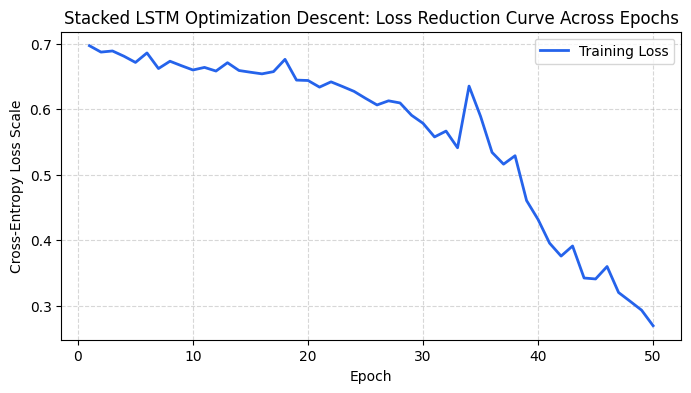

In [21]:
# ==========================================
# STEP 12: MODEL TRAINING AND LOSS OPTIMIZATION
# ==========================================

print("Initializing training configurations and optimization parameters...")

# 1. Define loss function and optimization framework
# CrossEntropyLoss is ideal for discrete classification targets (Up vs Down)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005) # Adam optimizer with a 0.005 learning rate

# 2. Establish baseline configuration parameters
epochs = 50          # Number of complete tracking passes through the training tensor
batch_size = 16      # Number of window samples processed per backward propagation pass

print(f"Beginning training loop across {epochs} epochs...")

# Track loss metrics over time to verify optimization decay gradients
loss_history = []

for epoch in range(epochs):
    model.train() # Set the system explicitly to active training configuration mode
    
    permutation = torch.randperm(X_train.size(0))
    epoch_losses = []
    
    # Process the sequence tensors in mini-batches to optimize stability
    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        # Zero out residual mathematical gradients from previous steps
        optimizer.zero_grad()
        
        # Execute the forward pass propagation loop
        outputs = model(batch_x)
        
        # Calculate loss deviation metrics against true directional categories
        loss = criterion(outputs, batch_y)
        
        # Backpropagate gradients through the hidden neural gates
        loss.backward()
        
        # Adjust internal gate weights based on optimization calculations
        optimizer.step()
        
        epoch_losses.append(loss.item())
        
    mean_epoch_loss = np.mean(epoch_losses)
    loss_history.append(mean_epoch_loss)
    
    # Print metrics every 5 passes to monitor optimization progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Mean Loss Value: {mean_epoch_loss:.4f}")

print("\nTraining Loop Complete!")

# Plot the training loss reduction curve to verify the network is learning
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, color="#2563EB", linewidth=2, label="Training Loss")
plt.title("Stacked LSTM Optimization Descent: Loss Reduction Curve Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss Scale")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# STEP 13: OUT-OF-SAMPLE VALIDATION TESTING
# ==========================================

print("Switching model to evaluation mode and processing out-of-sample test tensors...")

# 1. Set the model to evaluation configuration mode
# This turns off the dropout regularizations so we can get stable, deterministic outputs
model.eval()

with torch.no_grad(): # Disable mathematical gradient tracking to maximize computing speed
    # Pass our unseen test features through the optimized neural network layers
    test_logits = model(X_test)
    
    # Convert output logit numbers into hard probability class choices (0 or 1)
    # torch.max(..., 1) extracts the index of the highest probability value
    _, test_predictions = torch.max(test_logits, dim=1)

# 2. Convert PyTorch evaluation tensors back into standard NumPy arrays for scikit-learn
y_true_np = y_test.numpy()
y_pred_np = test_predictions.numpy()

# 3. Calculate core Data Science classification metrics
accuracy  = accuracy_score(y_true_np, y_pred_np)
precision = precision_score(y_true_np, y_pred_np, zero_division=0)
recall    = recall_score(y_true_np, y_pred_np, zero_division=0)
f1        = f1_score(y_true_np, y_pred_np, zero_division=0)

print("\nOut-of-Sample Performance Metrics Summary:")
print(f"• Classification Accuracy: {accuracy * 100:.2f}%")
print(f"• Precision Score:         {precision * 100:.2f}%")
print(f"• Recall Score:            {recall * 100:.2f}%")
print(f"• F1-Score Baseline:       {f1 * 100:.2f}%")

# 4. Generate and display the structural Confusion Matrix array
cm = confusion_matrix(y_true_np, y_pred_np)
print("\nConfusion Matrix Array:")
print(f"                     Predicted Down   Predicted Up")
print(f"Actual Down Market:       {cm[0][0]}               {cm[0][1]}")
print(f"Actual Up Market:         {cm[1][0]}               {cm[1][1]}")


Switching model to evaluation mode and processing out-of-sample test tensors...

Out-of-Sample Performance Metrics Summary:
• Classification Accuracy: 60.00%
• Precision Score:         57.69%
• Recall Score:            83.33%
• F1-Score Baseline:       68.18%

Confusion Matrix Array:
                     Predicted Down   Predicted Up
Actual Down Market:       6               11
Actual Up Market:         3               15


Initializing event-driven trading simulation under market frictions...

Financial Simulation Performance Summary:
• Total Trading Operations Triggered: 15 orders
• AI Strategy Net Cumulative Return:   -3.58%
• Buy-and-Hold Benchmark Return:       -3.55%


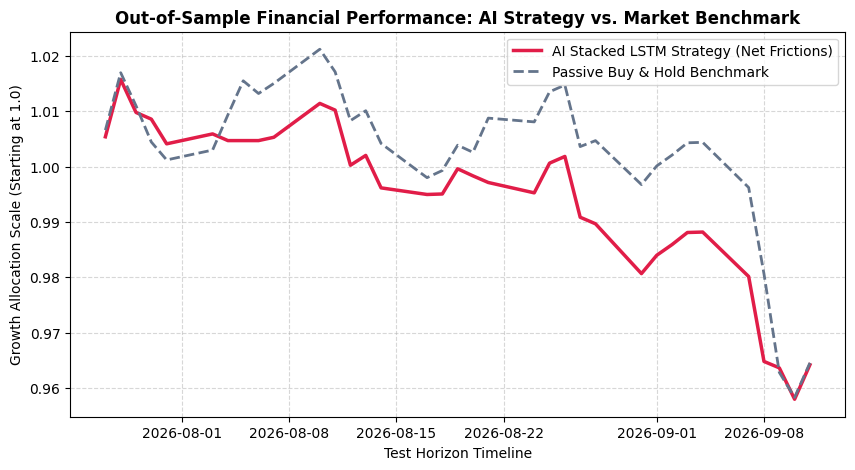

In [23]:
# ==========================================
# STEP 14: FRICTION-ADJUSTED TRADING BACKTESTER
# ==========================================

print("Initializing event-driven trading simulation under market frictions...")

# 1. Extract the actual out-of-sample test returns for the evaluation period
# We align our index with the last 35 trading days corresponding to our test tensor set
test_dates = df_master.index[split_idx + LOOKBACK_WINDOW:]
swiss_test_returns = df_master.loc[test_dates, 'Swiss_Returns'].values

# 2. Define trading cost parameters (Frictions)
TRANSACTION_FEE = 0.0010  # 10 basis points (0.1%) per executed order
SLIPPAGE = 0.0002         # 2 basis points (0.02%) execution price degradation

# 3. Initialize tracking vectors for our financial simulation loop
capital_history = [1.0]   # Start with a normalized capital baseline of 1.0 (or 100%)
current_position = 0      # 0 means Flat (No Position), 1 means Long (Holding the Asset)
total_trades = 0

for t in range(len(y_pred_np)):
    ai_signal = y_pred_np[t]          # 1 = Predict Up, 0 = Predict Down
    actual_market_return = swiss_test_returns[t]
    
    # Extract our previous capital baseline balance
    previous_capital = capital_history[-1]
    
    # --- AUTOMATED EXECUTION LOGIC ENGINE ---
    if ai_signal == 1: # AI predicts an Up-market movement
        if current_position == 0:
            # BUY ORDER EXECUTED: Pay fee and slippage up front
            trade_cost = TRANSACTION_FEE + SLIPPAGE
            net_capital = previous_capital * (1.0 - trade_cost)
            # Grow capital by the actual market return overnight
            new_capital = net_capital * (1.0 + actual_market_return)
            current_position = 1
            total_trades += 1
        else:
            # ALREADY LONG: Simply accumulate ongoing daily market return
            new_capital = previous_capital * (1.0 + actual_market_return)
    
    else: # AI predicts a Down-market movement
        if current_position == 1:
            # SELL/CLOSE ORDER EXECUTED: Pay fee and slippage to exit to cash
            trade_cost = TRANSACTION_FEE + SLIPPAGE
            new_capital = previous_capital * (1.0 - trade_cost)
            current_position = 0
            total_trades += 1
        else:
            # ALREADY FLAT: Safe in cash, capital returns remain completely flat (0%)
            new_capital = previous_capital

    capital_history.append(new_capital)

# Remove the initial seeding value to align shapes with time index rows
strategy_equity_curve = np.array(capital_history[1:])
benchmark_equity_curve = np.cumprod(1.0 + swiss_test_returns)

# 4. Calculate final quantitative financial metrics
final_strategy_return = (strategy_equity_curve[-1] - 1.0) * 100
final_benchmark_return = (benchmark_equity_curve[-1] - 1.0) * 100

print("\nFinancial Simulation Performance Summary:")
print(f"• Total Trading Operations Triggered: {total_trades} orders")
print(f"• AI Strategy Net Cumulative Return:   {final_strategy_return:.2f}%")
print(f"• Buy-and-Hold Benchmark Return:       {final_benchmark_return:.2f}%")

# 5. Visualizing the Financial Equity Growth Curves
plt.figure(figsize=(10, 5))
plt.plot(test_dates, strategy_equity_curve, label="AI Stacked LSTM Strategy (Net Frictions)", color="#E11D48", linewidth=2.5)
plt.plot(test_dates, benchmark_equity_curve, label="Passive Buy & Hold Benchmark", color="#64748B", linestyle="--", linewidth=2)
plt.title("Out-of-Sample Financial Performance: AI Strategy vs. Market Benchmark", fontsize=12, fontweight='bold')
plt.xlabel("Test Horizon Timeline")
plt.ylabel("Growth Allocation Scale (Starting at 1.0)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()
